In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import cv2
import tensorflow as tf
from tensorflow import keras
from keras import layers
from functools import partial

import warnings
warnings.filterwarnings('ignore')
AUTO = tf.data.experimental.AUTOTUNE

In [3]:
from zipfile import ZipFile

data_path = 'data/dog-breed-identification.zip'

with ZipFile(data_path, 'r') as zip:
    zip.extractall()
    print('The data set has been extracted.')

The data set has been extracted.


In [4]:
df = pd.read_csv('labels.csv')
df.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [5]:
df.shape

(10222, 2)

In [6]:
df['breed'].nunique()

120

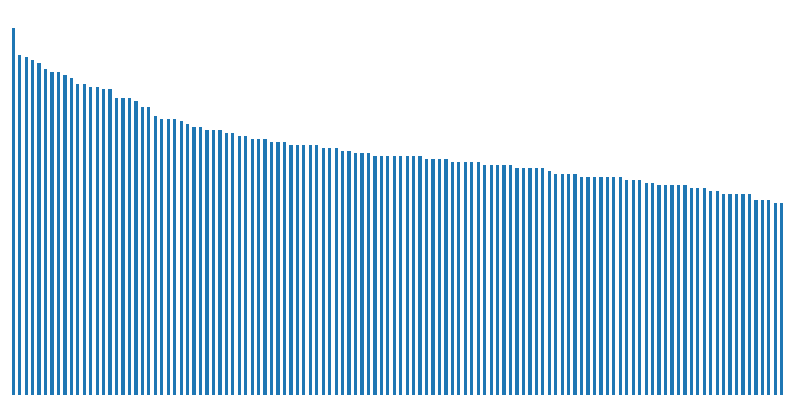

In [7]:
plt.figure(figsize=(10, 5))
df['breed'].value_counts().plot.bar()
plt.axis('off')
plt.show()

In [8]:
df['filepath'] = 'train/' + df['id'] + '.jpg'
df.head()

,id,breed,filepath
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,train/000bec180eb18c7604dcecc8fe0dba07.jpg
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,train/001513dfcb2ffafc82cccf4d8bbaba97.jpg
2,001cdf01b096e06d78e9e5112d419397,pekinese,train/001cdf01b096e06d78e9e5112d419397.jpg
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick,train/00214f311d5d2247d5dfe4fe24b2303d.jpg
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever,train/0021f9ceb3235effd7fcde7f7538ed62.jpg


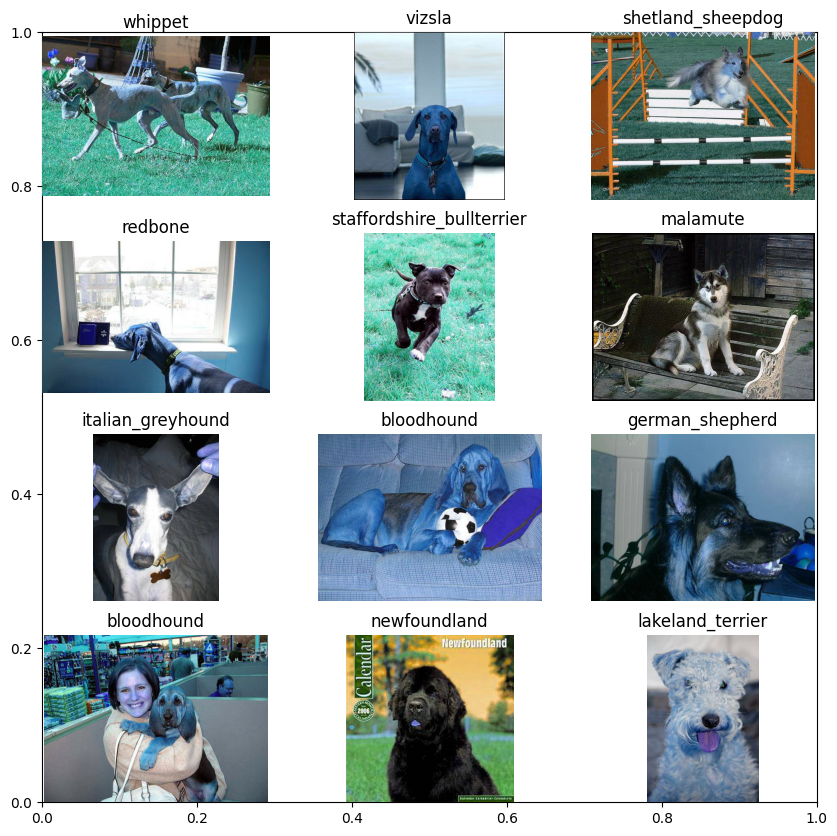

In [9]:
plt.subplots(figsize=(10, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)

    # Selecting a random image
    # index from the dataframe.
    k = np.random.randint(0, len(df))
    img = cv2.imread(df.loc[k, 'filepath'])
    plt.imshow(img)
    plt.title(df.loc[k, 'breed'])
    plt.axis('off')
plt.show()

In [10]:
le = LabelEncoder()
df['breed'] = le.fit_transform(df['breed'])
df.head()

,id,breed,filepath
0,000bec180eb18c7604dcecc8fe0dba07,19,train/000bec180eb18c7604dcecc8fe0dba07.jpg
1,001513dfcb2ffafc82cccf4d8bbaba97,37,train/001513dfcb2ffafc82cccf4d8bbaba97.jpg
2,001cdf01b096e06d78e9e5112d419397,85,train/001cdf01b096e06d78e9e5112d419397.jpg
3,00214f311d5d2247d5dfe4fe24b2303d,15,train/00214f311d5d2247d5dfe4fe24b2303d.jpg
4,0021f9ceb3235effd7fcde7f7538ed62,49,train/0021f9ceb3235effd7fcde7f7538ed62.jpg


In [11]:
features = df['filepath']
target = df['breed']

X_train, X_val, Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.15,
                                      random_state=10)

X_train.shape, X_val.shape

((8688,), (1534,))

In [12]:
import albumentations as A

transforms_train = A.Compose([
    A.VerticalFlip(p=0.2),
    A.HorizontalFlip(p=0.7),
    A.CoarseDropout(p=0.5),
    A.RandomGamma(p=0.5),
    A.RandomBrightnessContrast(p=1)
])

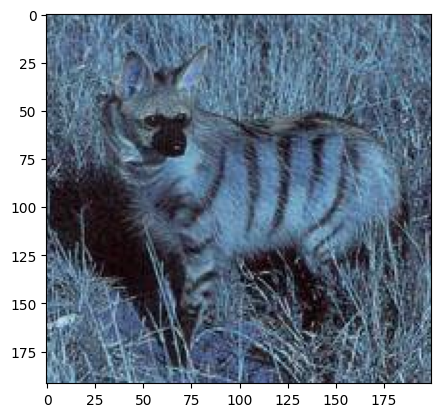

In [13]:
img = cv2.imread('train/00792e341f3c6eb33663e415d0715370.jpg')
plt.imshow(img)
plt.show()

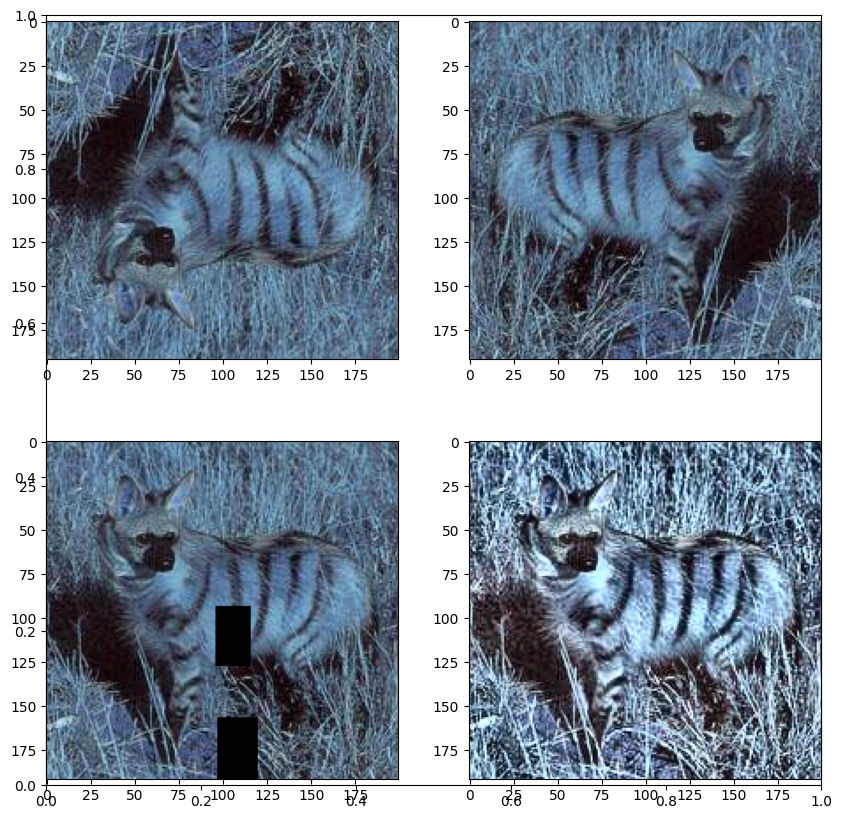

In [14]:
augments = [A.VerticalFlip(p=1), A.HorizontalFlip(p=1),
            A.CoarseDropout(p=1), A.CLAHE(p=1)]

plt.subplots(figsize=(10, 10))
for i, aug in enumerate(augments):
    plt.subplot(2, 2, i+1)
    aug_img = aug(image=img)['image']
    plt.imshow(aug_img)
plt.show()

In [15]:
def aug_fn(img):
    aug_data = transforms_train(image=img)
    aug_img = aug_data['image']

    return aug_img


@tf.function
def process_data(img, label):
    aug_img = tf.numpy_function(aug_fn,
                                [img],
                                Tout=tf.float32)

    return img, label


def decode_image(filepath, label=None):

    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img)
    img = tf.image.resize(img, [128, 128])
    img = tf.cast(img, tf.float32) / 255.0

    if label == None:
        return img

    return img, tf.one_hot(indices=label,
                           depth=120,
                           dtype=tf.float32)

In [16]:
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, Y_train))
    .map(decode_image, num_parallel_calls=AUTO)
    .map(partial(process_data), num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, Y_val))
    .map(decode_image, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

In [17]:
for img, label in train_ds.take(1):
  print(img.shape, label.shape)

(32, 128, 128, 3) (32, 120)


In [18]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

pre_trained_model = InceptionV3(
    input_shape=(128, 128, 3),
    weights='imagenet',
    include_top=False
)

In [19]:
len(pre_trained_model.layers)

311

In [20]:
for layer in pre_trained_model.layers: 
  layer.trainable = False

last_layer = pre_trained_model.get_layer('mixed7') 
# Access the output shape from the output tensor of the layer
print('last layer output shape: ', last_layer.output.shape) 
last_output = last_layer.output

last layer output shape:  (None, 6, 6, 768)


In [21]:
# Model Architecture
x = layers.Flatten()(last_output)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.BatchNormalization()(x)
output = layers.Dense(120, activation='softmax')(x)

model = keras.Model(pre_trained_model.input, output)

# Model Compilation
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

class myCallback(tf.keras.callbacks.Callback):
	def on_epoch_end(self, epoch, logs={}):
		if logs.get('val_auc') is not None and logs.get('val_auc') > 0.99:
			print('\n Validation accuracy has reached upto 90% so, stopping further training.')
			self.model.stop_training = True

es = EarlyStopping(patience=3,
                monitor='val_auc',
                restore_best_weights=True,
                mode='max')

lr = ReduceLROnPlateau(monitor='val_loss',
					patience=2,
					factor=0.5,
					verbose=1)

In [23]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=50,
                    verbose=1,
                    callbacks=[es, lr, myCallback()])

Epoch 1/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 59s 192ms/step - accuracy: 0.1577 - loss: 3.7666 - val_accuracy: 0.3357 - val_loss: 2.5386 - learning_rate: 0.0010
Epoch 2/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 51s 186ms/step - accuracy: 0.4791 - loss: 2.0427 - val_accuracy: 0.4068 - val_loss: 2.3179 - learning_rate: 0.0010
Epoch 3/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 51s 187ms/step - accuracy: 0.7521 - loss: 1.0261 - val_accuracy: 0.3742 - val_loss: 2.3986 - learning_rate: 0.0010
Epoch 4/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8955 - loss: 0.4942
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
272/272 ━━━━━━━━━━━━━━━━━━━━ 51s 186ms/step - accuracy: 0.9245 - loss: 0.4054 - val_accuracy: 0.3664 - val_loss: 2.5144 - learning_rate: 0.0010
Epoch 5/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 50s 184ms/step - accuracy: 0.9847 - loss: 0.1332 - val_accuracy: 0.4113 - val_loss: 2.2993 - learning_rate: 5.0000e-04
Epoch 6/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 52s 189ms/step - accuracy: 0

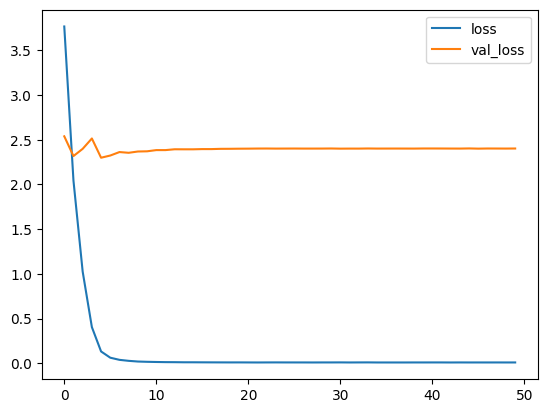

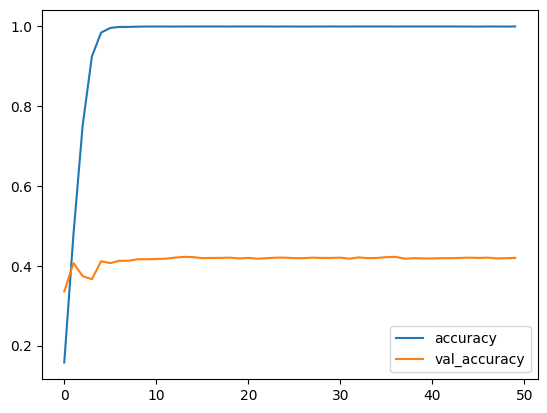

In [25]:
history_df = pd.DataFrame(history.history)

history_df.loc[:, ['loss', 'val_loss']].plot()

history_df.loc[:, ['accuracy', 'val_accuracy']].plot()

plt.show()

In [26]:
model.save("dog_breed_model.keras")

In [27]:
from tensorflow import keras

loaded_model = keras.models.load_model("dog_breed_model.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


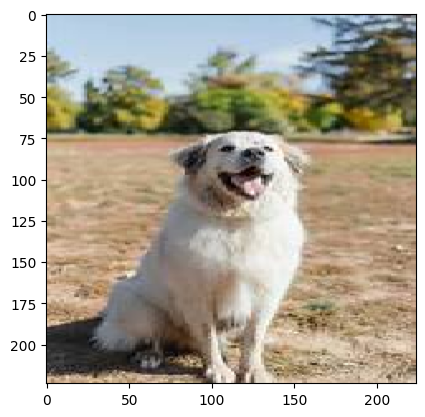

In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    "test_image.jpg",
    target_size=(224,224)
)

plt.imshow(img)
plt.show()

In [29]:
from tensorflow import keras

model = keras.models.load_model("dog_breed_model.keras")

In [30]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [31]:
print(model.input_shape)

(None, 128, 128, 3)


In [33]:
img = image.load_img(
    "test_image.jpg",
    target_size=(128,128)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

print(img_array.shape)

(1, 128, 128, 3)


In [34]:
predictions = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 944ms/step


In [36]:
print(predictions.shape)

(1, 120)


In [37]:
print(np.argmax(predictions))

52


In [38]:
img_array.shape

(1, 128, 128, 3)

In [40]:
model.input_shape

(None, 128, 128, 3)

In [41]:
print(img_array.shape)

(1, 128, 128, 3)


In [42]:
print(predictions.shape)

(1, 120)


In [43]:
predicted_class = np.argmax(predictions)

print(predicted_class)

52


In [44]:
predicted_breed = le.inverse_transform([predicted_class])

print(predicted_breed)

['great_pyrenees']


In [45]:
confidence = np.max(predictions)

print(confidence)

0.58220667


In [46]:
top5 = np.argsort(predictions[0])[-5:][::-1]

for i in top5:
    print(le.inverse_transform([i])[0], predictions[0][i])

great_pyrenees 0.58220667
english_setter 0.073650084
clumber 0.04280421
pekinese 0.038528673
maltese_dog 0.033940013


In [47]:
model.save("dog_breed_model.keras")

In [48]:
import os

base_path = "test_image"

breed_folders = os.listdir(base_path)

print("Total breed folders:", len(breed_folders))
print(breed_folders[:5])

Total breed folders: 120
['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu']


In [49]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "test_image/n02085620-Chihuahua/n02085620_7.jpg",
    target_size=(128,128)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

predictions = model.predict(img_array)

predicted_class = np.argmax(predictions[0])

predicted_breed = le.inverse_transform([predicted_class])

print(predicted_breed[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
chihuahua


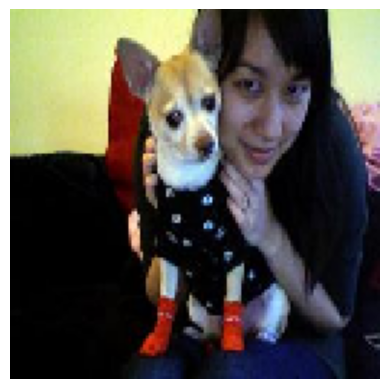

In [50]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis('off')
plt.show()

In [51]:
import os

breed_folder = "test_image/n02085620-Chihuahua"

images = os.listdir(breed_folder)

print("Total images:", len(images))
print(images[:5])

Total images: 152
['n02085620_10074.jpg', 'n02085620_10131.jpg', 'n02085620_10621.jpg', 'n02085620_1073.jpg', 'n02085620_10976.jpg']


In [52]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

folder_path = "test_image/n02085620-Chihuahua"

correct = 0
total = 0

for file_name in os.listdir(folder_path):

    img_path = os.path.join(folder_path, file_name)

    img = image.load_img(img_path, target_size=(128,128))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)

    predicted_class = np.argmax(prediction[0])

    predicted_breed = le.inverse_transform([predicted_class])[0]

    total += 1

    if predicted_breed == "chihuahua":
        correct += 1

print("Correct:", correct)
print("Total:", total)
print("Accuracy:", round(correct/total*100,2), "%")

Correct: 80
Total: 152
Accuracy: 52.63 %


In [53]:
print("chihuahua" in le.classes_)

True


In [54]:
from collections import Counter

predictions_list = []

folder_path = "test_image/n02085620-Chihuahua"

for file_name in os.listdir(folder_path):

    img_path = os.path.join(folder_path, file_name)

    img = image.load_img(img_path, target_size=(128,128))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)

    predicted_class = np.argmax(prediction[0])

    predicted_breed = le.inverse_transform([predicted_class])[0]

    predictions_list.append(predicted_breed)

print(Counter(predictions_list).most_common(10))

[('chihuahua', 80), ('pembroke', 11), ('toy_terrier', 7), ('italian_greyhound', 4), ('miniature_pinscher', 4), ('basenji', 4), ('mexican_hairless', 3), ('pomeranian', 3), ('miniature_schnauzer', 2), ('french_bulldog', 2)]


In [55]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

folder_path = "test_image/n02088364-beagle"

correct = 0
total = 0

for file_name in os.listdir(folder_path):

    img_path = os.path.join(folder_path, file_name)

    img = image.load_img(img_path, target_size=(128,128))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)

    predicted_class = np.argmax(prediction[0])

    predicted_breed = le.inverse_transform([predicted_class])[0]

    total += 1

    if predicted_breed == "beagle":
        correct += 1

print("Correct:", correct)
print("Total:", total)
print("Accuracy:", round(correct/total*100,2), "%")

Correct: 131
Total: 195
Accuracy: 67.18 %


In [56]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

folder_path = "test_image/n02086079-Pekinese"

correct = 0
total = 0

for file_name in os.listdir(folder_path):

    img_path = os.path.join(folder_path, file_name)

    img = image.load_img(img_path, target_size=(128,128))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)

    predicted_class = np.argmax(prediction[0])

    predicted_breed = le.inverse_transform([predicted_class])[0]

    total += 1

    if predicted_breed == "pekinese":
        correct += 1

print("Correct:", correct)
print("Total:", total)
print("Accuracy:", round(correct/total*100,2), "%")

Correct: 93
Total: 149
Accuracy: 62.42 %


In [57]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

folder_path = "test_image/n02086910-papillon"

correct = 0
total = 0

for file_name in os.listdir(folder_path):

    img_path = os.path.join(folder_path, file_name)

    img = image.load_img(img_path, target_size=(128,128))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)

    predicted_class = np.argmax(prediction[0])

    predicted_breed = le.inverse_transform([predicted_class])[0]

    total += 1

    if predicted_breed == "papillon":
        correct += 1

print("Correct:", correct)
print("Total:", total)
print("Accuracy:", round(correct/total*100,2), "%")

Correct: 149
Total: 196
Accuracy: 76.02 %


In [58]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

folder_path = "test_image/n02089867-Walker_hound"

correct = 0
total = 0

for file_name in os.listdir(folder_path):

    img_path = os.path.join(folder_path, file_name)

    img = image.load_img(img_path, target_size=(128,128))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)

    predicted_class = np.argmax(prediction[0])

    predicted_breed = le.inverse_transform([predicted_class])[0]

    total += 1

    if predicted_breed == "walker_hound":
        correct += 1

print("Correct:", correct)
print("Total:", total)
print("Accuracy:", round(correct/total*100,2), "%")

Correct: 84
Total: 153
Accuracy: 54.9 %


In [59]:
import os

base_path = "test_image"

total_images = 0

for breed_folder in os.listdir(base_path):
    
    folder_path = os.path.join(base_path, breed_folder)
    
    if os.path.isdir(folder_path):
        total_images += len(os.listdir(folder_path))

print("Total Images:", total_images)

Total Images: 20580


In [60]:
print(le.classes_[:20])

['affenpinscher' 'afghan_hound' 'african_hunting_dog' 'airedale'
 'american_staffordshire_terrier' 'appenzeller' 'australian_terrier'
 'basenji' 'basset' 'beagle' 'bedlington_terrier' 'bernese_mountain_dog'
 'black-and-tan_coonhound' 'blenheim_spaniel' 'bloodhound' 'bluetick'
 'border_collie' 'border_terrier' 'borzoi' 'boston_bull']


In [61]:
import os

base_path = "test_image"

for breed_folder in os.listdir(base_path)[:20]:
    actual_breed = breed_folder.split("-")[-1].lower()
    print(actual_breed, "->", actual_breed in le.classes_)

chihuahua -> True
japanese_spaniel -> True
maltese_dog -> True
pekinese -> True
tzu -> False
blenheim_spaniel -> True
papillon -> True
toy_terrier -> True
rhodesian_ridgeback -> True
afghan_hound -> True
basset -> True
beagle -> True
bloodhound -> True
bluetick -> True
tan_coonhound -> False
walker_hound -> True
english_foxhound -> True
redbone -> True
borzoi -> True
irish_wolfhound -> True


In [62]:
import os

base_path = "test_image"

false_labels = []

for breed_folder in os.listdir(base_path):

    actual_breed = breed_folder.split("-")[-1].lower()

    if actual_breed not in le.classes_:
        false_labels.append(actual_breed)

print(false_labels)
print("Total mismatches:", len(false_labels))

['tzu', 'tan_coonhound', 'haired_fox_terrier', 'coated_wheaten_terrier', 'coated_retriever', 'coated_retriever', 'haired_pointer']
Total mismatches: 7


In [63]:
import os

base_path = "test_image"

for breed_folder in os.listdir(base_path):

    actual_breed = breed_folder.split("-")[-1].lower()

    if actual_breed not in le.classes_:
        print(breed_folder)

n02086240-Shih-Tzu
n02089078-black-and-tan_coonhound
n02095314-wire-haired_fox_terrier
n02098105-soft-coated_wheaten_terrier
n02099267-flat-coated_retriever
n02099429-curly-coated_retriever
n02100236-German_short-haired_pointer


In [64]:
import os

base_path = "test_image"

false_labels = []

for breed_folder in os.listdir(base_path):

    folder_path = os.path.join(base_path, breed_folder)

    if not os.path.isdir(folder_path):
        continue

    if "-" not in breed_folder:
        continue

    actual_breed = breed_folder.split("-", 1)[1].lower()

    if actual_breed not in le.classes_:
        false_labels.append(actual_breed)

print(false_labels)
print("Total mismatches:", len(false_labels))

[]
Total mismatches: 0


In [65]:
import os
import random
from tensorflow.keras.preprocessing import image
import numpy as np

base_path = "test_image"

correct = 0
total = 0

for breed_folder in os.listdir(base_path):

    folder_path = os.path.join(base_path, breed_folder)

    if not os.path.isdir(folder_path):
        continue

    actual_breed = breed_folder.split("-", 1)[1].lower()

    images = os.listdir(folder_path)

    sample_images = random.sample(
        images,
        min(20, len(images))
    )

    for file_name in sample_images:

        img_path = os.path.join(
            folder_path,
            file_name
        )

        img = image.load_img(
            img_path,
            target_size=(128,128)
        )

        img_array = image.img_to_array(img)
        img_array = np.expand_dims(
            img_array,
            axis=0
        )
        img_array = img_array / 255.0

        prediction = model.predict(
            img_array,
            verbose=0
        )

        predicted_class = np.argmax(
            prediction[0]
        )

        predicted_breed = le.inverse_transform(
            [predicted_class]
        )[0]

        total += 1

        if predicted_breed == actual_breed:
            correct += 1

print("Correct:", correct)
print("Total:", total)
print(
    "Accuracy:",
    round(correct/total*100,2),
    "%"
)

Correct: 1545
Total: 2400
Accuracy: 64.38 %
